In [1]:
import os
import argparse
import matplotlib.pyplot as plt
from fABBA import JABBA
import torch
from datasets.dataset_dict import DatasetDict
from datasets import Dataset
from transformers import AutoModelForSequenceClassification, BitsAndBytesConfig
from peft import get_peft_model, LoraConfig, TaskType, prepare_model_for_kbit_training
from transformers import AutoTokenizer, DataCollatorWithPadding
import numpy as np

from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import TrainingArguments, Trainer

import pandas as pd
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import warnings


torch.cuda.empty_cache()

2024-10-01 04:29:11.752743: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-01 04:29:12.700600: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


# Set Hyperparameters

In [15]:
warnings.filterwarnings("ignore")

global label_weights
global num_classes
global model_tokenizer
global MAX_LENGTH
global batch_size

epochs = 20
batch_size = 4
MAX_LENGTH = 1536
num_classes = 4
lora_r = 16
model_name = "mistral-7B"  #  "mistral-7B"    "llama2-7B"
data_name = "mitbih"  # "mitbih"
jabba = JABBA(tol=0.001, init='agg', alpha=0.01, scl=3, verbose=0)

In [11]:

# Python program to convert a list to string
def listToString(s):
    # initialize an empty string
    str1 = ""
    # traverse in the string
    for ele in s:
        str1 += ele + ' '
    # return string
    return str1

def compute_metrics(pred):
    # print('######################################')
    # print(pred.predictions.shape)
    # print('######################################')
    # print(pred.predictions.argmax(-1))
    # print('######################################')
    # print(pred.label_ids.shape)

    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    Precision, Recall, f1, _ = precision_recall_fscore_support(labels, preds, average='micro')
    acc = accuracy_score(labels, preds)
    return {
        'Accuracy': acc,
        'F1': f1,
        'Precision': Precision,
        'Recall': Recall
    }

class WeightedCELossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels")
        # Get model's predictions
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Compute custom loss
        loss_fct = torch.nn.CrossEntropyLoss(
            weight=torch.tensor(label_weights, device=model.device, dtype=logits.dtype))
        loss = loss_fct(logits, labels).mean()
        # loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss


class MSELossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels")
        # Get model's predictions
        outputs = model(**inputs)
        logits = outputs.get("logits")

        print('######################################')
        print(logits.squeeze())
        print('######################################')
        print(inputs.pop("labels"))
        print('######################################')
        # print(pred.label_ids.shape)

        # Compute MSE loss
        #         loss = F.mse_loss(logits.squeeze(), labels.float())
        loss = F.mse_loss(logits.squeeze(), labels.float()) / batch_size
        #         total_loss += loss.item()

        return (loss, outputs) if return_outputs else loss


def model_preprocessing_function(examples):
    return model_tokenizer(examples['text'], truncation=True, padding='max_length', max_length=MAX_LENGTH)


def fnirs_process(current_dir, input_folder):

    # column_name = ['AB_I_O', 'AB_PHI_O', 'AB_I_DO', 'AB_PHI_DO', 'CD_I_O', 'CD_PHI_O', 'CD_I_DO', 'CD_PHI_DO', 'label']
    # data_df = pd.DataFrame([], columns=column_name)

    data_all_transformed, target_all_transformed = [], []

    subject_seg = 426
    seg_length = 210 # sampling rate is 5.2Hz, one trial is 2 second length,
    for file_i in range(len(input_folder)): #2):#
        directory = input_folder[file_i]  ## 57: Haptics  41: FordA  33: Earthquakes  24: DistalPhalanxTW
        input_data = current_dir + "/" + directory

        ##   data reading
        data_subject = pd.read_csv(input_data, header=None).to_numpy()
        data_subject = data_subject[1:, :]
        data_subject_size = data_subject.shape

        subject_seg_temp = 0
        seg_length_temp = 0
        AA = np.zeros([subject_seg - 6, data_subject_size[1] - 1])
        BB = np.zeros([seg_length, data_subject_size[1] - 1])
        data_subject_transformed = np.zeros(
            [int(data_subject_size[0] / subject_seg) * int(subject_seg / seg_length), data_subject_size[1] - 1, seg_length])
        target_subject_transformed = np.zeros([int(data_subject_size[0] / subject_seg) * int(subject_seg / seg_length)],
                                              dtype=int)
        for i_subject_seg in range(int(data_subject_size[0] / subject_seg)):
            AA = data_subject[i_subject_seg * subject_seg + 3:(i_subject_seg + 1) * subject_seg - 3, :]
            subject_seg_temp += 1
            for i_seg_length in range(int(subject_seg / seg_length)):
                BB = AA[i_seg_length * seg_length:(i_seg_length + 1) * seg_length, :-1]
                data_subject_transformed[seg_length_temp, :, :] = np.transpose(BB)
                target_subject_transformed[seg_length_temp] = AA[i_seg_length * seg_length, -1]
                seg_length_temp += 1

        data_all_transformed.extend(data_subject_transformed)
        target_all_transformed.extend(target_subject_transformed)

    return np.array(data_all_transformed), np.array(target_all_transformed)


def fnirs_process_slide_window(current_dir, input_folder):

    # column_name = ['AB_I_O', 'AB_PHI_O', 'AB_I_DO', 'AB_PHI_DO', 'CD_I_O', 'CD_PHI_O', 'CD_I_DO', 'CD_PHI_DO', 'label']
    # data_df = pd.DataFrame([], columns=column_name)

    data_all_transformed, target_all_transformed = [], []

    subject_seg = 150  # sampling rate is 5.2Hz, we set 30 second length,
    for file_i in range(len(input_folder)): #2):#
        directory = input_folder[file_i]
        input_data = current_dir + "/" + directory

        ##   data reading
        data_subject = pd.read_csv(input_data, header=None).to_numpy()
        data_subject = data_subject[1:, :]

        data_subject_size = data_subject.shape

        subject_seg_temp = 0
        AA = np.zeros([subject_seg, data_subject_size[1]])
        data_subject_transformed = np.zeros([int(data_subject_size[0] / subject_seg), subject_seg, data_subject_size[1] - 2])
        target_subject_transformed = np.zeros([int(data_subject_size[0] / subject_seg)],
                                              dtype=int)
        for i_subject_seg in range(int(data_subject_size[0] / subject_seg)):
            AA = data_subject[i_subject_seg * subject_seg:(i_subject_seg + 1) * subject_seg, :]
            data_subject_transformed[subject_seg_temp, :, :] = AA[:, :-2]   #  np.transpose(BB)
            target_subject_transformed[subject_seg_temp] = AA[75, -1]
            subject_seg_temp += 1

        data_all_transformed.extend(data_subject_transformed)
        target_all_transformed.extend(target_subject_transformed)

    return np.array(data_all_transformed), np.array(target_all_transformed)



# Load LLM and Tokenizer

In [4]:
##  Quantization Coonfig
quantization_config = BitsAndBytesConfig(
    # Load the model with 4-bit quantization
    load_in_4bit=True,
    # Use double quantization
    bnb_4bit_use_double_quant=True,
    # Use 4-bit Normal Float for storing the base model weights in GPU memory
    bnb_4bit_quant_type="nf4",
    # De-quantize the weights to 16-bit (Brain) float before the forward/backward pass
    bnb_4bit_compute_dtype=torch.bfloat16,
)



# lora config
if model_name == "roberta-large":

    model_checkpoint = "roberta-large"
    model_tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, add_prefix_space=True)
    model_tokenizer.pad_token_id = model_tokenizer.eos_token_id
    model_tokenizer.pad_token = model_tokenizer.eos_token

#     model_input = AutoModelForSequenceClassification.from_pretrained(
#         pretrained_model_name_or_path=model_checkpoint,
#         num_labels=num_classes,
#         device_map="auto"
#     )

#     # Data collator for padding a batch of examples to the maximum length seen in the batch
#     model_data_collator = DataCollatorWithPadding(tokenizer=model_tokenizer)

#     model_input.config.pad_token_id = model_input.config.eos_token_id
#     model_input = prepare_model_for_kbit_training(model_input)

#     roberta_peft_config = LoraConfig(
#         task_type=TaskType.SEQ_CLS,
#         r=lora_r,
#         lora_alpha=16,
#         lora_dropout=0.05,
#         bias="none",
#         modules_to_save=["embed_tokens"],
#     )
#     model_input = get_peft_model(model_input, roberta_peft_config)
elif model_name == "mistral-7B":

    model_checkpoint = 'mistralai/Mistral-7B-Instruct-v0.1'
    model_tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, add_prefix_space=True)
    model_tokenizer.pad_token_id = model_tokenizer.eos_token_id
    model_tokenizer.pad_token = model_tokenizer.eos_token

#     model_input = AutoModelForSequenceClassification.from_pretrained(
#         pretrained_model_name_or_path=model_checkpoint,
#         num_labels=num_classes,
#         device_map="auto"
#     )

#     # Data collator for padding a batch of examples to the maximum length seen in the batch
#     model_data_collator = DataCollatorWithPadding(tokenizer=model_tokenizer)

#     model_input.config.pad_token_id = model_input.config.eos_token_id
#     model_input = prepare_model_for_kbit_training(model_input)

#     mistral_lora_config = LoraConfig(
#         task_type=TaskType.SEQ_CLS,
#         r=lora_r,  # the dimension of the low-rank matrices
#         lora_alpha=16,  # scaling factor for LoRA activations vs pre-trained weight activations
#         target_modules=[
#             "q_proj",
#             "k_proj",
#             "v_proj",
#             "o_proj",
#             "gate_proj",
#             "up_proj",
#             "down_proj",
#             "lm_head",
#         ],
#         lora_dropout=0.05,  # dropout probability of the LoRA layers
#         bias='none',  # wether to train bias weights, set to 'none' for attention layers
#         modules_to_save=["embed_tokens"],
#     )
#     model_input = get_peft_model(model_input, mistral_lora_config)
elif model_name == "llama2-7B":

    model_checkpoint = "starmpcc/Asclepius-Llama2-7B"
    model_tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, add_prefix_space=True)
    model_tokenizer.pad_token_id = model_tokenizer.eos_token_id
    model_tokenizer.pad_token = model_tokenizer.eos_token

#     model_input = AutoModelForSequenceClassification.from_pretrained(
#         pretrained_model_name_or_path=model_checkpoint,
#         num_labels=num_classes,
#         device_map="auto"
#     )

#     # Data collator for padding a batch of examples to the maximum length seen in the batch
#     model_data_collator = DataCollatorWithPadding(tokenizer=model_tokenizer)

#     model_input.config.pad_token_id = model_input.config.eos_token_id
#     model_input = prepare_model_for_kbit_training(model_input)

#     llama_peft_config = LoraConfig(
#         task_type=TaskType.SEQ_CLS,
#         r=lora_r,
#         lora_alpha=16,
#         lora_dropout=0.05,
#         bias="none",
#         target_modules=[
#             "q_proj",
#             "k_proj",
#             "v_proj",
#             "o_proj",
#             "gate_proj",
#             "up_proj",
#             "down_proj",
#             "lm_head",
#         ],
#         modules_to_save=["embed_tokens"],
#     )
#     model_input = get_peft_model(model_input, llama_peft_config)

else:
    print("Please input correct models!")

# model_input.print_trainable_parameters()
# model_input = model_input.cuda()


In [5]:
mistral_vocab = model_tokenizer.get_vocab()
vocab_list = list(mistral_vocab.keys())

vocab_list_new = []
for i_vac in vocab_list:
    if '▁' in i_vac:
        vocab_list_new.append(i_vac.replace('▁', ''))
    else:
        vocab_list_new.append(i_vac)

# Load data from the Medical Tiem Series dataset

In [16]:
###############   Medical Time Series data   ###############
if data_name == 'eeg-eye-state':

    from scipy.io import arff
    data = arff.loadarff('data/eeg-eye-state/EEG_Eye_State.arff')
    data_df = pd.DataFrame(data[0])
    data_df['eyeDetection'] = data_df['eyeDetection'].astype('int')
    num_classes = 2

    ### one segment has 250ms, as sampling rate is 128
    seg_length = 16

    from scipy import stats
    from copy import deepcopy

    temp_data_frame = deepcopy(data_df)
    clean_data_frame = deepcopy(data_df)
    for column in temp_data_frame.columns[:-1]:
        temp_data_frame[str(column) + 'z_score'] = stats.zscore(temp_data_frame[column])
        clean_data_frame[column] = temp_data_frame.loc[temp_data_frame[str(column) + 'z_score'].abs() <= 3][column]

    clean_data_frame.interpolate(method='linear', inplace=True)

    temp_data_frame = deepcopy(clean_data_frame)
    clean_data_frame_second = deepcopy(clean_data_frame)

    for column in temp_data_frame.columns[:-1]:
        temp_data_frame[str(column) + 'z_score'] = stats.zscore(temp_data_frame[column])
        clean_data_frame_second[column] = temp_data_frame.loc[temp_data_frame[str(column) + 'z_score'].abs() <= 3][
            column]

    clean_data_frame_second.interpolate(method='linear', inplace=True)

    # clean_data_frame_second_normalized = 2 * (clean_data_frame_second - clean_data_frame_second.mean()) / (
    #         clean_data_frame_second.max() - clean_data_frame_second.min())
    #
    # clean_data_frame_second_normalized = clean_data_frame_second_normalized.to_numpy()

    # Initialize the StandardScaler
    scaler = StandardScaler()
    # Fit the scaler to the training data and transform it
    clean_data_frame_second_normalized = scaler.fit_transform(clean_data_frame_second)


    data_labels = data_df['eyeDetection'].to_numpy()

    total_seg_num = int(len(data_labels) / seg_length)

    X_data = np.zeros([total_seg_num, seg_length, 14], dtype=float)
    y_data = np.zeros([total_seg_num], dtype=int)

    seg_num = 0
    for i_seg in range(total_seg_num):
        X_data[seg_num, :, :] = clean_data_frame_second_normalized[i_seg * seg_length:(i_seg + 1) * seg_length, :-1]
        temp_a = data_labels[i_seg * seg_length:(i_seg + 1) * seg_length]
        # print(temp_a)
        if np.mean(temp_a) > 0.5:
            y_data[seg_num] = 1
        seg_num += 1

    from sklearn.utils.class_weight import compute_class_weight
    label_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_data), y=y_data)

    symbols = jabba.fit_transform(X_data, alphabet_set=vocab_list_new)
    reconstruction = jabba.inverse_transform(symbols)
    reconst_same_shape = jabba.recast_shape(reconstruction)  # recast into original shape

    print('##############################################################')
    print("The length of one symbols element is:" + str(len(symbols[10])))
    print("The length of used symbols is:" + str(jabba.parameters.centers.shape[0]))

    symbols_convert = []
    for i_data in range(len(symbols)):
        # print(i_data)
        symbols_convert.append(listToString(list(symbols[i_data])))

    train_data_symbolic, test_data_symbolic, train_target_symbolic, test_target_symbolic = train_test_split(
        symbols_convert, y_data, test_size=0.2)

elif data_name == 'ptbdb':

    abnormal_df = pd.read_csv('data/mitbih/ptbdb_abnormal.csv', header=None)
    normal_df = pd.read_csv('data/mitbih/ptbdb_normal.csv', header=None)

    abnormal_length = abnormal_df.shape[0]
    normal_length = normal_df.shape[0]

    y_data = np.concatenate((np.zeros([abnormal_length], dtype=int), np.ones([normal_length], dtype=int)), axis=0)
    X_data = pd.concat([abnormal_df, normal_df]).to_numpy()

    arranged_seq = np.random.randint(len(y_data), size=len(y_data))
    X_data = X_data[arranged_seq, :]
    y_data = y_data[arranged_seq]

    # Assign meaningful names to the class labels based on domain knowledge
    class_names = {
        0: "Abnormal",
        1: "Normal",
    }

    num_classes = len(class_names)

    from sklearn.utils.class_weight import compute_class_weight
    label_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_data), y=y_data)

    # Initialize the StandardScaler
    scaler = StandardScaler()

    # Fit the scaler to the training data and transform it
    X_data = scaler.fit_transform(X_data)
    symbols = jabba.fit_transform(X_data, alphabet_set=vocab_list_new)
    # reconstruction = jabba.inverse_transform(symbols)
    print('##############################################################')
    print("The length of one symbols element is:" + str(len(symbols[100])))
    print("The length of used symbols is:" + str(jabba.parameters.centers.shape[0]))

    symbols_convert = []
    for i_data in range(len(symbols)):
        symbols_convert.append(listToString(list(symbols[i_data])))

    train_data_symbolic, test_data_symbolic, train_target_symbolic, test_target_symbolic = train_test_split(
        symbols_convert, y_data, test_size=0.2)

elif data_name == 'fnirs':

    ###############   fnirs data   ###############
    num_classes = 4
    current_dir = "data/fNIRS-mental-workload/size_30sec_150ts_stride_03ts"
    fNIRS_folder = os.listdir(current_dir)

    directory_all = sorted(fNIRS_folder)

    train_data_subjects, test_data_subjects = train_test_split(directory_all, test_size=0.05)
    # train_all_transformed, train_target_all_transformed = fnirs_process(fnirs_process_slide_window, train_data_subjects)
    # test_all_transformed, test_target_all_transformed = fnirs_process(current_dir, test_data_subjects)

    train_all_transformed, train_target_all_transformed = fnirs_process_slide_window(current_dir, train_data_subjects)
    test_all_transformed, test_target_all_transformed = fnirs_process_slide_window(current_dir, test_data_subjects)

    # Initialize the StandardScaler
    scaler = StandardScaler()
    # Fit the scaler to the training data and transform it
    train_all_transformed_initialized = scaler.fit_transform(np.reshape(train_all_transformed, (train_all_transformed.shape[0]*train_all_transformed.shape[1], train_all_transformed.shape[2])))
    train_all_transformed = np.reshape(train_all_transformed_initialized, (train_all_transformed.shape[0], train_all_transformed.shape[1], train_all_transformed.shape[2]))

    test_all_transformed_initialized = scaler.transform(np.reshape(test_all_transformed, (test_all_transformed.shape[0]*test_all_transformed.shape[1], test_all_transformed.shape[2])))
    test_all_transformed = np.reshape(test_all_transformed_initialized, (test_all_transformed.shape[0], test_all_transformed.shape[1], test_all_transformed.shape[2]))

    train_length, test_length, = train_all_transformed.shape[0], test_all_transformed.shape[0]

    arranged_seq = np.random.randint(len(train_target_all_transformed), size=len(train_target_all_transformed))
    train_all_transformed = train_all_transformed[arranged_seq, :, :]
    train_target_all_transformed = train_target_all_transformed[arranged_seq]

    X_data = np.concatenate((train_all_transformed, test_all_transformed), axis=0)
    y_data = np.concatenate((train_target_all_transformed, test_target_all_transformed), axis=0)

    # X_data = np.transpose(X_data, (2, 1, 0))
    X_data_temp = np.reshape(X_data, (X_data.shape[0]*X_data.shape[1], X_data.shape[2]))
    scaler = preprocessing.MinMaxScaler(feature_range=(0, 1))
    X_data_temp = scaler.fit_transform(X_data_temp)
    X_data = np.reshape(X_data_temp, (X_data.shape[0], X_data.shape[2], X_data.shape[1]))

    # X_data = np.transpose(X_data, (0, 2, 1))
    symbols = jabba.fit_transform(X_data)
    reconstruction = jabba.inverse_transform(symbols)
    reconst_same_shape = jabba.recast_shape(reconstruction)  # recast into original shape

    print('##############################################################')
    print("The length of one symbols element is:" + str(len(symbols[50])))
    print("The length of used symbols is:" + str(jabba.parameters.centers.shape[0]))

    index_fnirs = 2
    for i_plot in range(8):
        #         plt.subplot(1, 7, i_plot+1)
        plt.plot(X_data[index_fnirs, :, i_plot], label='Ground Truth')
        plt.plot(reconst_same_shape[index_fnirs, :, i_plot], label='Reconstruction')

        # Cross_Correlation = cross_correlation(X_data[i_plot, :], reconstruction[i_plot])
        # plt.rcParams.update({'font.size': 20})
        # plt.title('Cross Correlation: ' + str("{:.3}".format(Cross_Correlation)), fontsize=20)

        plt.title('The length of symbols: ' + str(len(symbols[index_fnirs])), fontsize=20)
        plt.xlabel('Inout Length', fontsize=20)
        plt.ylabel('Feature ' + str(i_plot + 1), fontsize=20)

        plt.legend()
        plt.grid(True, axis='y')
        plt.tight_layout()
        # plt.savefig('Compression_Reproduction_img_S' + str(i_reconst) + '_Feature' + str(i_plot) + '.jpg')
        plt.show()
        plt.close()
            
    symbols_convert = []
    for i_data in range(len(symbols)):
        symbols_convert.append(listToString(list(symbols[i_data])))

    from sklearn.utils.class_weight import compute_class_weight
    label_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_data), y=y_data)

    train_data_symbolic_temp, test_data_symbolic, train_target_symbolic, test_target_symbolic = \
        symbols_convert[:train_length], symbols_convert[train_length:], y_data[:train_length], y_data[train_length:]

    train_data_symbolic = []
    arranged_seq = np.random.randint(len(train_target_symbolic), size=len(train_target_symbolic))
    for i_arranged_seq in arranged_seq:
        train_data_symbolic.append(train_data_symbolic_temp[i_arranged_seq])
    train_target_symbolic = train_target_symbolic[arranged_seq]

elif data_name == 'mitbih':

    train_df = pd.read_csv('data/mitbih/mitbih_train.csv', header=None)
    test_df = pd.read_csv('data//mitbih/mitbih_test.csv', header=None)

    train_length, test_length, = train_df.shape[0], test_df.shape[0]

    arranged_seq = np.random.randint(train_length, size=train_length)
    train_df = train_df.iloc[arranged_seq]

    data_df = pd.concat([train_df, test_df])
    # Assuming the target column is the last column
    target_column_index = data_df.shape[1] - 1

    # Get the unique values in the target column
    class_labels = data_df[target_column_index].unique()

    # Assign meaningful names to the class labels based on domain knowledge
    class_names = {
        0: "Normal Beats",
        1: "Supraventricular Ectopy Beats",
        2: "Ventricular Ectopy Beats",
        3: "Fusion Beats",
        4: "Unclassifiable Beats"
    }

    num_classes = len(class_names)
    # num_classes = 1


    # Print class labels with their assigned names
    for label in class_labels:
        print(f"Class label {label}: {class_names[label]}")

    X_data = data_df.drop(columns=[187]).to_numpy()

    y_data_temp = data_df[187].to_numpy()
    y_data = []
    for i_data in range(len(y_data_temp)):
        # print(i_data)
        y_data.append(int(y_data_temp[i_data]))
    y_data = np.array(y_data)

    from sklearn.utils.class_weight import compute_class_weight
    label_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_data), y=y_data)

    # Initialize the StandardScaler
    scaler = StandardScaler()

    # Fit the scaler to the training data and transform it
    X_data = scaler.fit_transform(X_data)


    symbols = jabba.fit_transform(X_data)
    reconstruction = jabba.inverse_transform(symbols)
    # reconst_same_shape = jabba.recast_shape(reconstruction)  # recast into original shape

    print('##############################################################')
    print("The length of one symbols element is:" + str(len(symbols[100])))
    print("The length of used symbols is:" + str(jabba.parameters.centers.shape[0]))

    for i_plot in range(10):
        #         plt.subplot(1, 7, i_plot+1)
        plt.plot(X_data[i_plot, :], label='Ground Truth')
        plt.plot(reconstruction[i_plot], label='Reconstruction')

        Cross_Correlation = cross_correlation(X_data[i_plot, :], reconstruction[i_plot])
        plt.rcParams.update({'font.size': 20})
        # plt.title('Cross Correlation: ' + str("{:.3}".format(Cross_Correlation)), fontsize=20)

        plt.title('The length of symbols: ' + str(len(symbols[i_plot])), fontsize=20)
        plt.xlabel('Inout Length', fontsize=20)
        plt.ylabel('Feature ' + str(i_plot + 1), fontsize=20)

        plt.legend()
        plt.grid(True, axis='y')
        plt.tight_layout()
        # plt.savefig('Compression_Reproduction_img_S' + str(i_reconst) + '_Feature' + str(i_plot) + '.jpg')
        plt.show()
        plt.close()

    symbols_convert = []
    for i_data in range(len(symbols)):
        # print(i_data)
        symbols_convert.append(listToString(list(symbols[i_data])))

    from sklearn.utils.class_weight import compute_class_weight
    label_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_data), y=y_data)

    # train_data_symbolic, test_data_symbolic, train_target_symbolic, test_target_symbolic = \
    #     symbols_convert[:train_length], symbols_convert[train_length:], y_data[:train_length], y_data[train_length:]

    train_data_symbolic, test_data_symbolic, train_target_symbolic, test_target_symbolic = \
        symbols_convert[:5000], symbols_convert[6000:8500], y_data[:5000], y_data[6000:8500]
    # train_data_symbolic, test_data_symbolic, train_target_symbolic, test_target_symbolic = train_test_split(
    #     symbols_convert, y_data, test_size=0.2)


Class label 0.0: Normal Beats
Class label 4.0: Unclassifiable Beats
Class label 1.0: Supraventricular Ectopy Beats
Class label 2.0: Ventricular Ectopy Beats
Class label 3.0: Fusion Beats
The length of used symbols is: 2926


KeyboardInterrupt: 

In [ ]:
index_fnirs = 2
for i_plot in range(14):
    #         plt.subplot(1, 7, i_plot+1)
    plt.plot(X_data[index_fnirs, :, i_plot], label='Ground Truth')
    plt.plot(reconst_same_shape[index_fnirs, :, i_plot], label='Reconstruction')

    # Cross_Correlation = cross_correlation(X_data[i_plot, :], reconstruction[i_plot])
    # plt.rcParams.update({'font.size': 20})
    # plt.title('Cross Correlation: ' + str("{:.3}".format(Cross_Correlation)), fontsize=20)

    plt.title('The length of symbols: ' + str(len(symbols[index_fnirs])), fontsize=20)
    plt.xlabel('Inout Length', fontsize=20)
    plt.ylabel('Feature ' + str(i_plot + 1), fontsize=20)

    plt.legend(fontsize=12)
    plt.grid(True, axis='y')
    plt.tight_layout()
#         plt.savefig('Compression_Reproduction_img_S' + data_name + '_Feature' + str(i_plot) + '.jpg')
    plt.show()
    plt.close()

In [7]:
reconst_same_shape = jabba.recast_shape(reconstruction)  # recast into original shape

print('##############################################################')
print("The length of one symbols element is:" + str(len(symbols[50])))
print("The length of used symbols is:" + str(jabba.parameters.centers.shape[0]))

##############################################################
The length of one symbols element is:661
The length of used symbols is:5831


In [8]:

data_TS = DatasetDict({
    'train': Dataset.from_dict({'label': train_target_symbolic, 'text': train_data_symbolic}),
    'test': Dataset.from_dict({'label': test_target_symbolic, 'text': test_data_symbolic})
})

model_tokenized_datasets = data_TS.map(model_preprocessing_function, batched=True)
model_tokenized_datasets.set_format("torch")


Map:   0%|          | 0/95232 [00:00<?, ? examples/s]

Map:   0%|          | 0/5952 [00:00<?, ? examples/s]

In [ ]:
X_data.shape

In [9]:
X_data.shape

(101184, 8, 150)

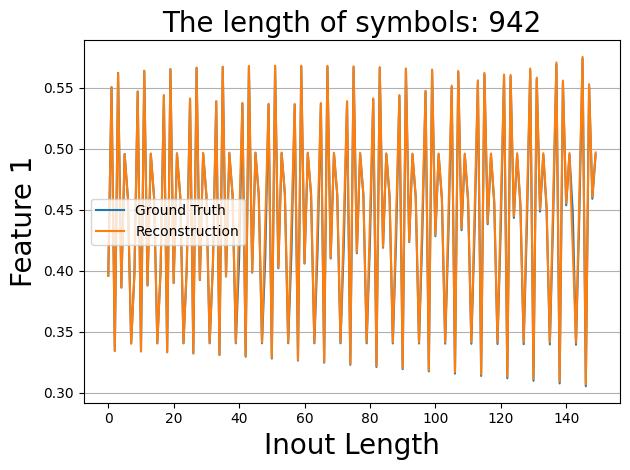

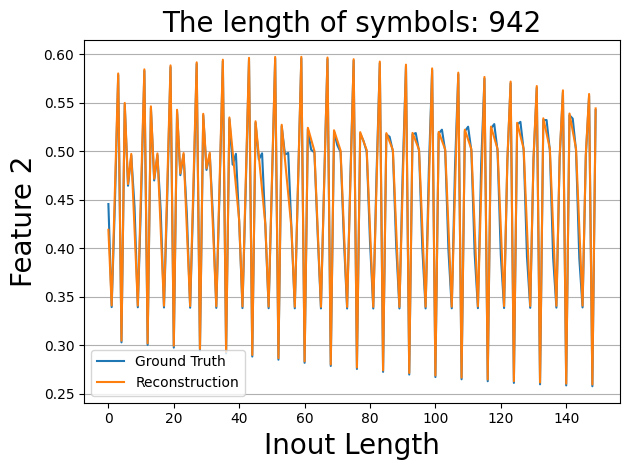

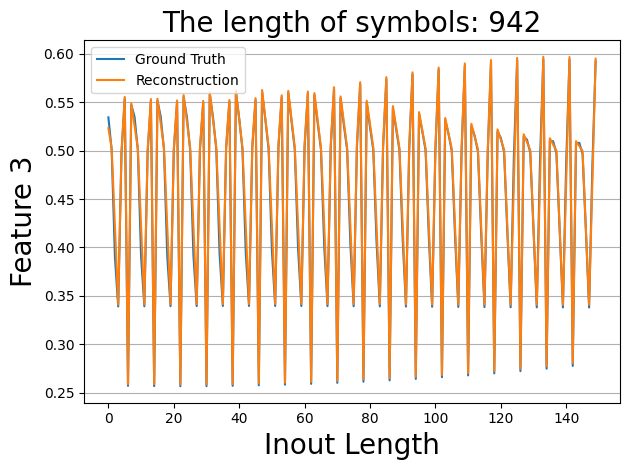

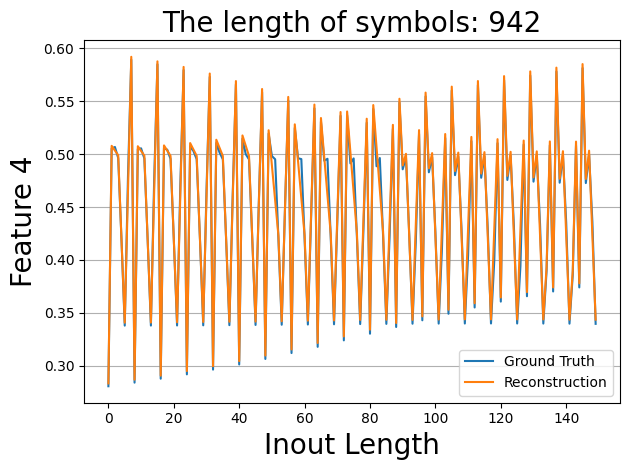

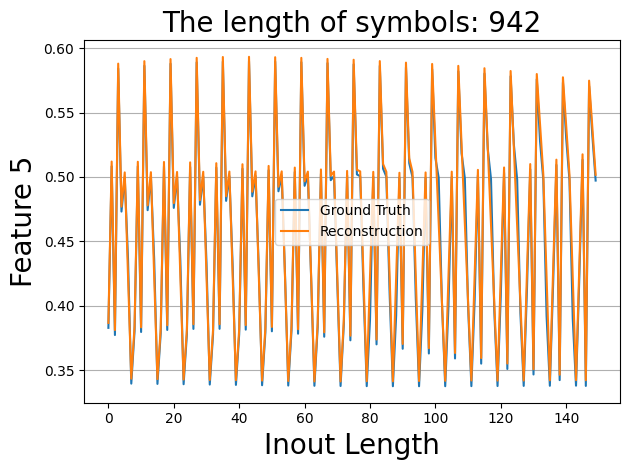

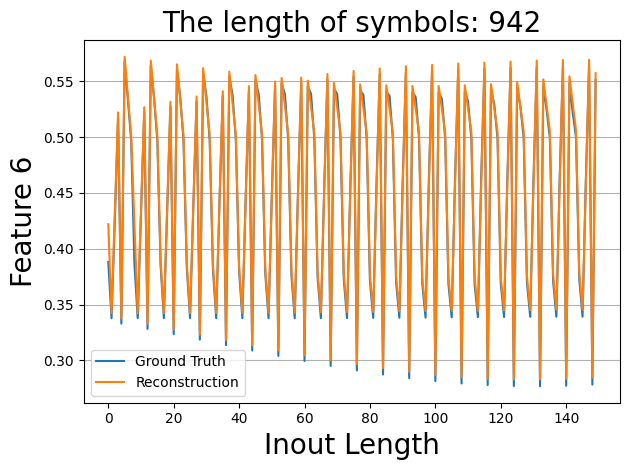

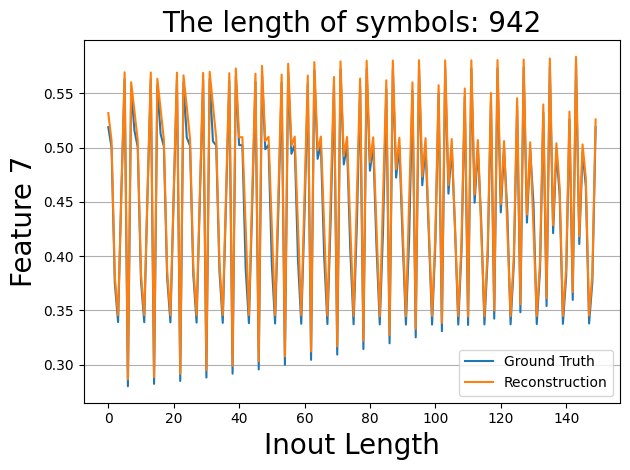

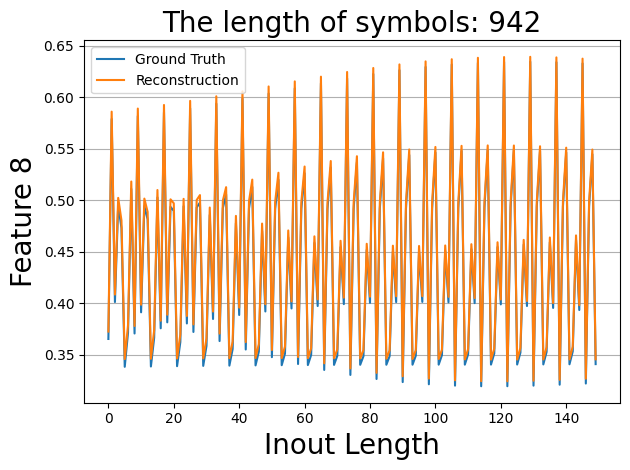

In [11]:
index_fnirs = 20
for i_plot in range(8):
    #         plt.subplot(1, 7, i_plot+1)
    plt.plot(X_data[index_fnirs, i_plot, :], label='Ground Truth')
    plt.plot(reconst_same_shape[index_fnirs, i_plot, :], label='Reconstruction')

    # Cross_Correlation = cross_correlation(X_data[i_plot, :], reconstruction[i_plot])
    # plt.rcParams.update({'font.size': 20})
    # plt.title('Cross Correlation: ' + str("{:.3}".format(Cross_Correlation)), fontsize=20)

    plt.title('The length of symbols: ' + str(len(symbols[index_fnirs])), fontsize=20)
    plt.xlabel('Inout Length', fontsize=20)
    plt.ylabel('Feature ' + str(i_plot + 1), fontsize=20)

    plt.legend()
    plt.grid(True, axis='y')
    plt.tight_layout()
    # plt.savefig('Compression_Reproduction_img_S' + str(i_reconst) + '_Feature' + str(i_plot) + '.jpg')
    plt.show()
    plt.close()
            

# Training

In [7]:

project = "ts-finetune-" + data_name
# b-instruct-v0.1-h
run_name = model_name + "-" + project
output_dir = "./" + run_name

training_args = TrainingArguments(
    output_dir=output_dir,
    learning_rate=2e-3,
    warmup_ratio=0.1,
    max_grad_norm=0.3,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=epochs,
    optim="paged_adamw_8bit",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    logging_dir="./logs",
    load_best_model_at_end=True,
    report_to="wandb",
    fp16=True,
    gradient_checkpointing=True,
    save_total_limit=2,
)

trainer_abba = WeightedCELossTrainer(
    model=model_input,
    args=training_args,
    train_dataset=model_tokenized_datasets['train'],
    eval_dataset=model_tokenized_datasets["test"],
    data_collator=model_data_collator,
    compute_metrics=compute_metrics,
)
trainer_abba.train()


NameError: name 'model_tokenized_datasets' is not defined